# 基于生活方式的肥胖等级探索性数据分析

本笔记本在**已完成清洗**的 `Obesity_data_clean.csv` 上开展：以生活方式相关变量（及年龄）做探索性分析，并排除性别、身高、体重、家族史等；**另将 `meals_per_day` 排除在本节图表与 Pearson 相关之外**（定稿建模是否使用该列以 `model_final.ipynb` 为准）。

**运行方式**：建议在 `try/analysis` 文件夹中打开本笔记本（或将 Jupyter 工作目录设为该文件夹），以便数据路径与输出图片目录正确解析。

分析结果图保存目录：`try/analysis/image/`。图中标题与坐标轴标签使用英文以便展示与投稿。


In [18]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Image, display

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 120

IMAGE_DIR = Path("image")
IMAGE_DIR.mkdir(parents=True, exist_ok=True)

TARGET = "obesity_level"

# 与 model_final 默认排除列一致；本笔记本另排除 meals_per_day，不参与下文探索性图表
DROP_BASE = ["gender", "height", "weight", "family_history", "obesity_level"]
EDA_EXTRA_DROP = ["meals_per_day"]
DROP_FOR_EDA = DROP_BASE + EDA_EXTRA_DROP

OBESITY_ORDER = [
    "Insufficient_Weight",
    "Normal_Weight",
    "Overweight_Level_I",
    "Overweight_Level_II",
    "Obesity_Type_I",
    "Obesity_Type_II",
    "Obesity_Type_III",
]


def resolve_data_path() -> Path:
    for p in (
        Path("Obesity_data_clean.csv"),
        Path("try/analysis/Obesity_data_clean.csv"),
    ):
        if p.exists():
            return p
    cwd = Path.cwd()
    for p in (cwd / "Obesity_data_clean.csv", cwd / "try" / "analysis" / "Obesity_data_clean.csv"):
        if p.exists():
            return p
    raise FileNotFoundError("未找到 Obesity_data_clean.csv，请将数据放在笔记本同目录或 try/analysis/ 下。")


DATA_PATH = resolve_data_path()
df = pd.read_csv(DATA_PATH)
df[TARGET] = pd.Categorical(df[TARGET], categories=OBESITY_ORDER, ordered=True)

X = df.drop(columns=[c for c in DROP_FOR_EDA if c in df.columns])
y = df[TARGET]

print(f"数据路径: {DATA_PATH.resolve()}")
print(f"样本量: n={len(df)}, 原始列数={df.shape[1]}")
print(f"本节探索性分析用特征矩阵 X 形状: {X.shape}")
df.head()


数据路径: D:\program\INT6184\try\analysis\Obesity_data_clean.csv
样本量: n=2087, 原始列数=17
建模用特征矩阵 X 形状: (2087, 12)


,gender,age,height,weight,family_history,high_cal_food,veg_consumption,meals_per_day,snacking,smoking,water_intake,calorie_monitor,physical_activity,screen_time,alcohol,transport,obesity_level
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


## 1. 数据说明

以下说明样本量、变量角色，以及**未进入 model_final 的变量**、**本笔记本单独不作图的变量**（`meals_per_day`）。


In [19]:
# 变量总览表（中文表头仅用于展示）
rows = []
for col in df.columns:
    dtype_str = str(df[col].dtype)
    if col == TARGET:
        role = "目标变量（7 分类）"
    elif col in EDA_EXTRA_DROP:
        role = "本笔记本 EDA 未使用（不作图）"
    elif col in DROP_BASE:
        role = "未进入 model_final 特征"
    elif col in X.columns:
        role = "本节 EDA 用特征"
    else:
        role = "其他"
    rows.append({"列名": col, "类型": dtype_str, "角色": role})

var_table = pd.DataFrame(rows)
display(var_table)

print(
    "\n未进入 model_final 输入特征的变量及理由：\n"
    "- gender / height / weight：主题聚焦生活方式；身高体重与肥胖标签强相关，易掩盖行为因素。\n"
    "- family_history：遗传与家庭因素，与「生活方式」主线区分，故不作为特征。\n"
    "- obesity_level：分类目标变量，不作为输入特征。\n"
    "\n本笔记本单独约定：\n"
    "- meals_per_day：不参与本节分布图、计数图、小提琴图与 Pearson 相关分析；定稿建模是否使用该变量以 model_final.ipynb 为准。\n"
)


,列名,类型,角色
0,gender,str,未进入模型
1,age,float64,建模特征
2,height,float64,未进入模型
3,weight,float64,未进入模型
4,family_history,str,未进入模型
5,high_cal_food,str,建模特征
6,veg_consumption,float64,建模特征
7,meals_per_day,float64,建模特征
8,snacking,str,建模特征
9,smoking,str,建模特征



未进入建模的变量及理由（与 model_final 一致）：
- gender / height / weight：主题聚焦生活方式；身高体重与肥胖标签强相关，易掩盖行为因素。
- family_history：遗传与家庭因素，与「生活方式」主线区分，故不作为特征。
- obesity_level：分类目标变量，不作为输入特征。



## 2. 目标变量分布

展示 7 个肥胖等级在清洗后数据中的频数与比例，用于说明类别是否大致均衡及后续分层划分的合理性。


C:\Users\Chris\AppData\Local\Temp\ipykernel_40024\1431732061.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=TARGET, order=OBESITY_ORDER, palette="viridis", ax=ax)


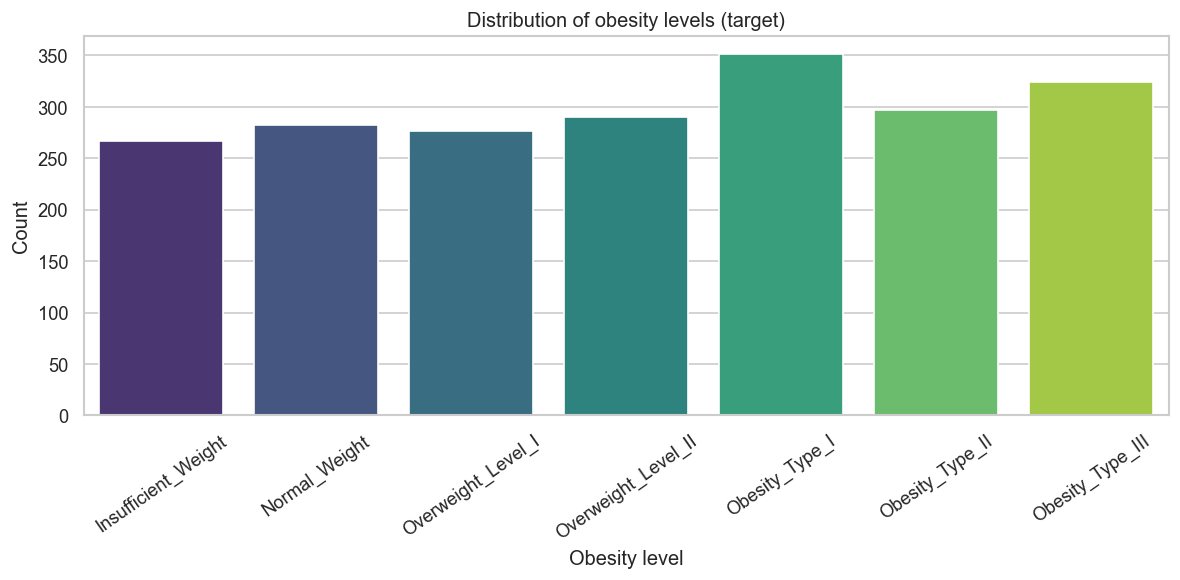

已保存: D:\program\INT6184\try\analysis\image\eda_target_distribution.png


,count,percent
obesity_level,,
Insufficient_Weight,267,12.79
Normal_Weight,282,13.51
Overweight_Level_I,276,13.22
Overweight_Level_II,290,13.90
Obesity_Type_I,351,16.82
Obesity_Type_II,297,14.23
Obesity_Type_III,324,15.52


最大类/最小类样本量比值: 1.31


In [20]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.countplot(data=df, x=TARGET, order=OBESITY_ORDER, palette="viridis", ax=ax)
ax.set_title("Distribution of obesity levels (target)")
ax.set_xlabel("Obesity level")
ax.set_ylabel("Count")
ax.tick_params(axis="x", rotation=35)
plt.tight_layout()
p = IMAGE_DIR / "eda_target_distribution.png"
plt.savefig(p, bbox_inches="tight")
plt.show()
print(f"已保存: {p.resolve()}")

counts = df[TARGET].value_counts().reindex(OBESITY_ORDER)
props = (counts / len(df) * 100).round(2)
balance = pd.DataFrame({"count": counts, "percent": props})
display(balance)
print(f"最大类/最小类样本量比值: {counts.max() / counts.min():.2f}")


## 3. 建模特征与肥胖等级的关系

对 **X 中全部建模用变量** 作图：分类变量用按肥胖等级配色的计数图，数值变量用小提琴图（含箱线）。用于直观展示生活方式因素与等级之间是否存在可辨识的模式。


建模用分类特征: ['high_cal_food', 'snacking', 'smoking', 'calorie_monitor', 'alcohol', 'transport']
建模用数值特征: ['age', 'veg_consumption', 'meals_per_day', 'water_intake', 'physical_activity', 'screen_time']


C:\Users\Chris\AppData\Local\Temp\ipykernel_40024\4264325298.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()


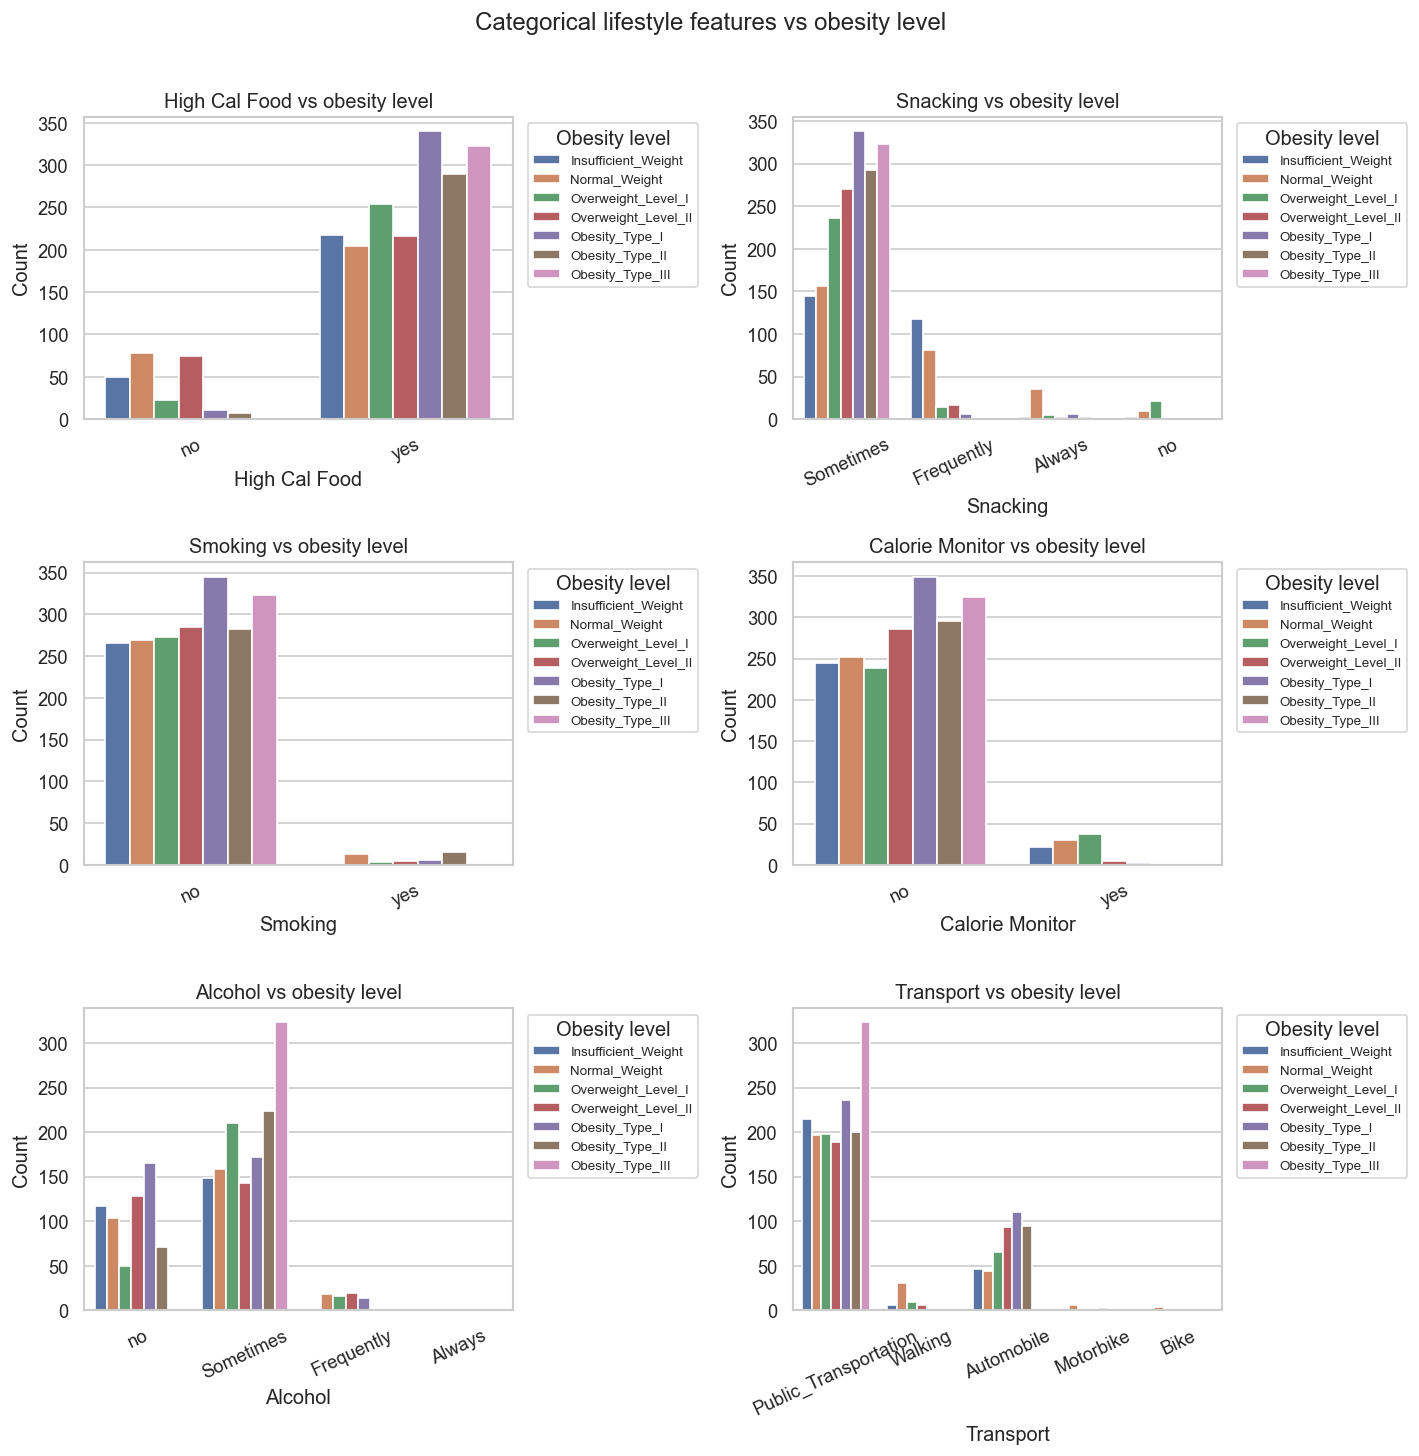

已保存: D:\program\INT6184\try\analysis\image\eda_categorical_vs_target_grid.png


In [21]:
cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
print("建模用分类特征:", cat_cols)
print("建模用数值特征:", num_cols)

n_cat = len(cat_cols)
if n_cat > 0:
    ncols = 2
    nrows = int(np.ceil(n_cat / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4 * nrows))
    axes = np.atleast_1d(axes).ravel()
    for i, col in enumerate(cat_cols):
        ax = axes[i]
        sns.countplot(data=df, x=col, hue=TARGET, hue_order=OBESITY_ORDER, ax=ax)
        ax.set_title(f"{col.replace('_', ' ').title()} vs obesity level")
        ax.set_xlabel(col.replace("_", " ").title())
        ax.set_ylabel("Count")
        ax.legend(title="Obesity level", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
        ax.tick_params(axis="x", rotation=25)
    for j in range(len(cat_cols), len(axes)):
        axes[j].set_visible(False)
    plt.suptitle("Categorical lifestyle features vs obesity level", y=1.01)
    plt.tight_layout()
    p = IMAGE_DIR / "eda_categorical_vs_target_grid.png"
    plt.savefig(p, bbox_inches="tight")
    plt.show()
    print(f"已保存: {p.resolve()}")
else:
    print("无分类特征，跳过。")


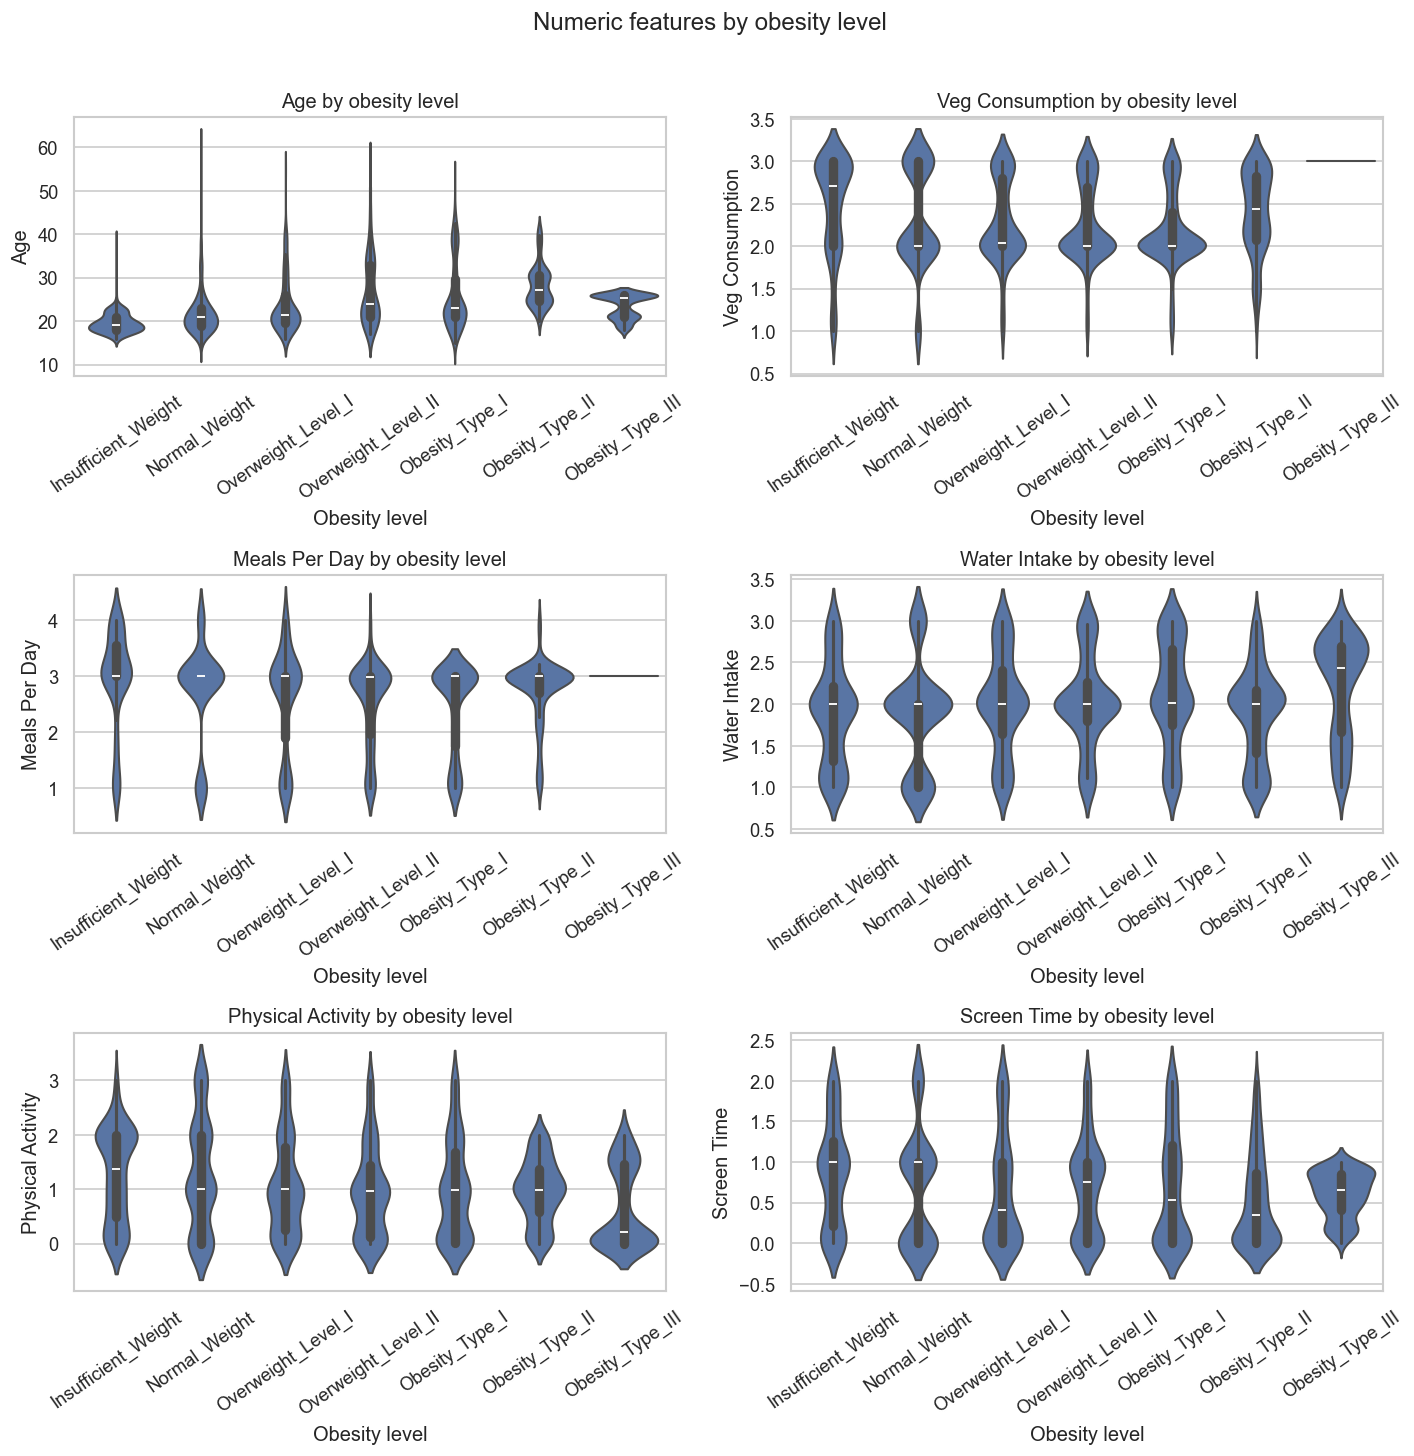

已保存: D:\program\INT6184\try\analysis\image\eda_numeric_vs_target_grid.png


In [22]:
n_num = len(num_cols)
if n_num > 0:
    ncols = 2
    nrows = int(np.ceil(n_num / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4 * nrows))
    axes = np.atleast_1d(axes).ravel()
    for i, col in enumerate(num_cols):
        ax = axes[i]
        sns.violinplot(data=df, x=TARGET, y=col, order=OBESITY_ORDER, ax=ax, inner="box")
        ax.set_title(f"{col.replace('_', ' ').title()} by obesity level")
        ax.set_xlabel("Obesity level")
        ax.set_ylabel(col.replace("_", " ").title())
        ax.tick_params(axis="x", rotation=35)
    for j in range(len(num_cols), len(axes)):
        axes[j].set_visible(False)
    plt.suptitle("Numeric features by obesity level", y=1.01)
    plt.tight_layout()
    p = IMAGE_DIR / "eda_numeric_vs_target_grid.png"
    plt.savefig(p, bbox_inches="tight")
    plt.show()
    print(f"已保存: {p.resolve()}")
else:
    print("无数值特征，跳过。")


## 4. 数据质量复检（清洗后）

在**当前清洗结果**上检查缺失、重复与数值变量的分布范围，作为进入建模前的质量说明。


各列缺失计数（清洗后）:


,missing_count,missing_pct
gender,0,0.0
age,0,0.0
height,0,0.0
weight,0,0.0
family_history,0,0.0
high_cal_food,0,0.0
veg_consumption,0,0.0
meals_per_day,0,0.0
snacking,0,0.0
smoking,0,0.0



完全重复行数: 0


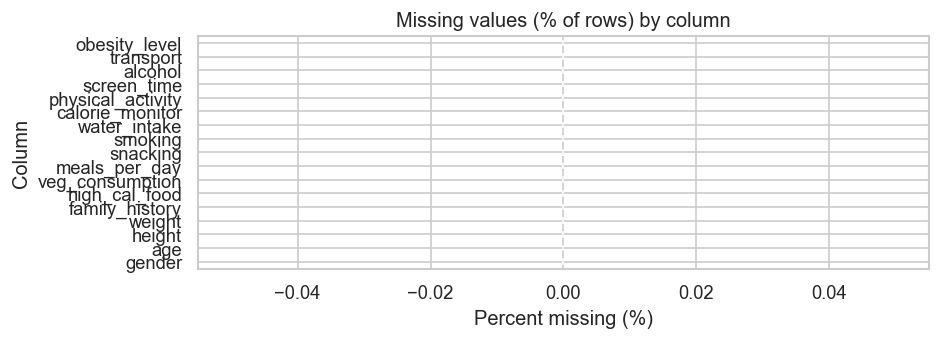

已保存: D:\program\INT6184\try\analysis\image\eda_missingness_overview.png


In [23]:
missing = df.isna().sum()
miss_pct = (missing / len(df) * 100).round(4)
miss_df = pd.DataFrame({"missing_count": missing, "missing_pct": miss_pct})
print("各列缺失计数（清洗后）:")
display(miss_df)

dup_n = df.duplicated().sum()
print(f"\n完全重复行数: {dup_n}")

fig, ax = plt.subplots(figsize=(8, max(3, len(df.columns) * 0.12)))
miss_df["missing_pct"].plot(kind="barh", ax=ax, color="steelblue")
ax.set_title("Missing values (% of rows) by column")
ax.set_xlabel("Percent missing (%)")
ax.set_ylabel("Column")
plt.tight_layout()
p = IMAGE_DIR / "eda_missingness_overview.png"
plt.savefig(p, bbox_inches="tight")
plt.show()
print(f"已保存: {p.resolve()}")


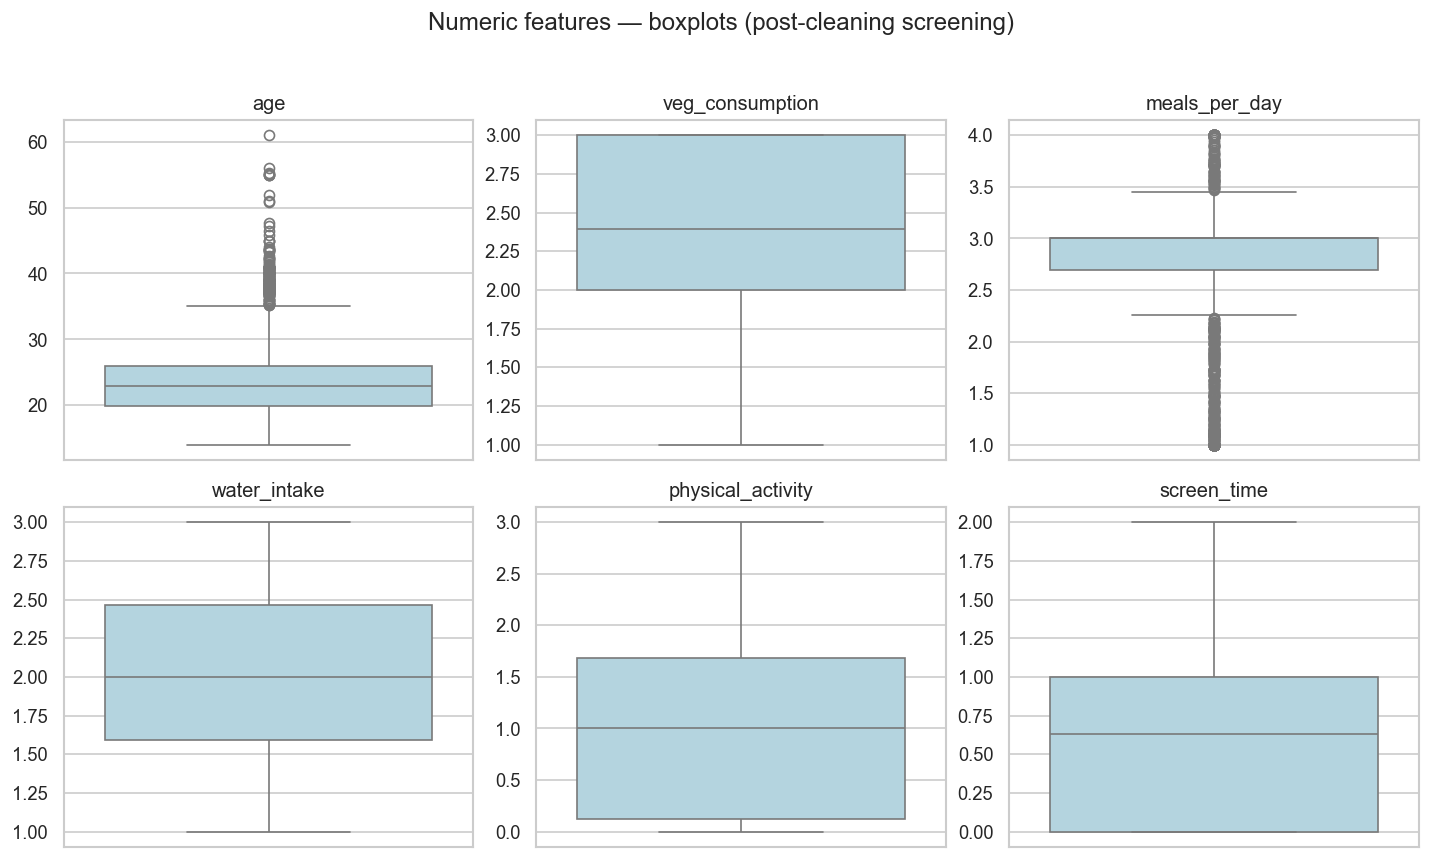

已保存: D:\program\INT6184\try\analysis\image\eda_numeric_boxplots_screening.png


,min,max,mean,50%
age,14.0,61.0,24.353,22.848
veg_consumption,1.0,3.0,2.421,2.396
meals_per_day,1.0,4.0,2.701,3.000
water_intake,1.0,3.0,2.005,2.000
physical_activity,0.0,3.0,1.013,1.000
screen_time,0.0,2.0,0.663,0.631


In [24]:
if num_cols:
    ncols = 3
    nrows = int(np.ceil(len(num_cols) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(12, 3.5 * nrows))
    axes = np.atleast_1d(axes).ravel()
    for i, col in enumerate(num_cols):
        sns.boxplot(y=df[col], ax=axes[i], color="lightblue")
        axes[i].set_title(col)
        axes[i].set_ylabel("")
    for j in range(len(num_cols), len(axes)):
        axes[j].set_visible(False)
    plt.suptitle("Numeric features — boxplots (post-cleaning screening)", y=1.02)
    plt.tight_layout()
    p = IMAGE_DIR / "eda_numeric_boxplots_screening.png"
    plt.savefig(p, bbox_inches="tight")
    plt.show()
    print(f"已保存: {p.resolve()}")

    summary = df[num_cols].describe().T
    display(summary[["min", "max", "mean", "50%"]].round(3))
else:
    print("无数值列，跳过箱线图。")


## 5. 补充：数值特征与有序肥胖指数的相关

将目标按等级顺序编码为整数，计算与数值特征的 Pearson 相关，仅作**探索性线性/单调趋势**参考，不能替代监督学习下的特征重要性。


weight               0.912
age                  0.279
veg_consumption      0.229
physical_activity   -0.206
water_intake         0.134
height               0.125
screen_time         -0.115
meals_per_day        0.011
Name: obesity_ordinal, dtype: float64

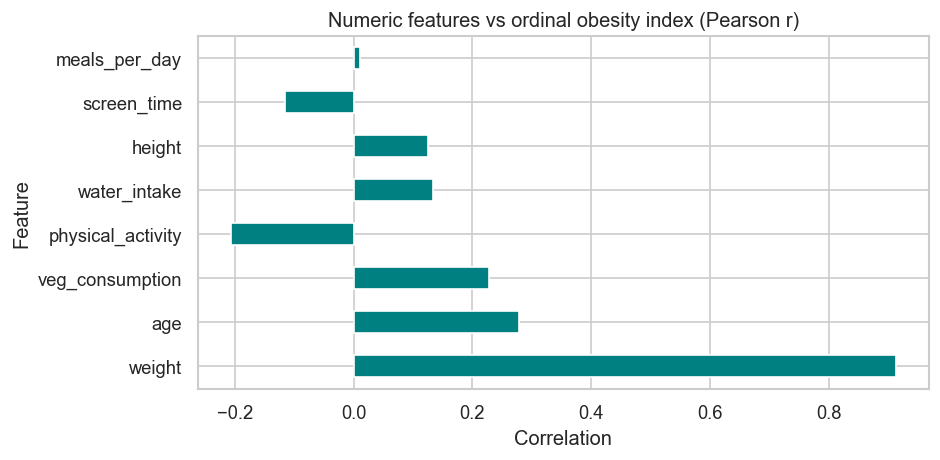

已保存: D:\program\INT6184\try\analysis\image\eda_numeric_corr_ordinal.png


In [25]:
tmp = df.copy()
tmp["obesity_ordinal"] = tmp[TARGET].cat.codes
num_only = [
    c
    for c in tmp.select_dtypes(include=[np.number]).columns.tolist()
    if c not in EDA_EXTRA_DROP
]
if "obesity_ordinal" in num_only:
    corr_series = tmp[num_only].corr()["obesity_ordinal"].drop("obesity_ordinal")
    corr_series = corr_series.reindex(corr_series.abs().sort_values(ascending=False).index)
    display(corr_series.round(3))

    fig, ax = plt.subplots(figsize=(8, 4))
    corr_series.plot(kind="barh", ax=ax, color="teal")
    ax.set_title("Numeric features vs ordinal obesity index (Pearson r)")
    ax.set_xlabel("Correlation")
    ax.set_ylabel("Feature")
    plt.tight_layout()
    p = IMAGE_DIR / "eda_numeric_corr_ordinal.png"
    plt.savefig(p, bbox_inches="tight")
    plt.show()
    print(f"已保存: {p.resolve()}")
else:
    print("无法计算相关。")


## 6. 与建模结果互证

若已在 `try/final_model/` 下运行 `model_final.ipynb` 并生成 **混淆矩阵**与 **XGBoost 特征重要性** 图，下方将尝试加载展示。请将定性结论写进报告：探索性图形中与等级相关的变量，是否与模型重要性排序大体一致；混淆矩阵中哪些相邻等级更易混淆。


尝试加载建模输出图（若存在）:

D:\program\INT6184\try\final_model\feature_importance_xgboost.png


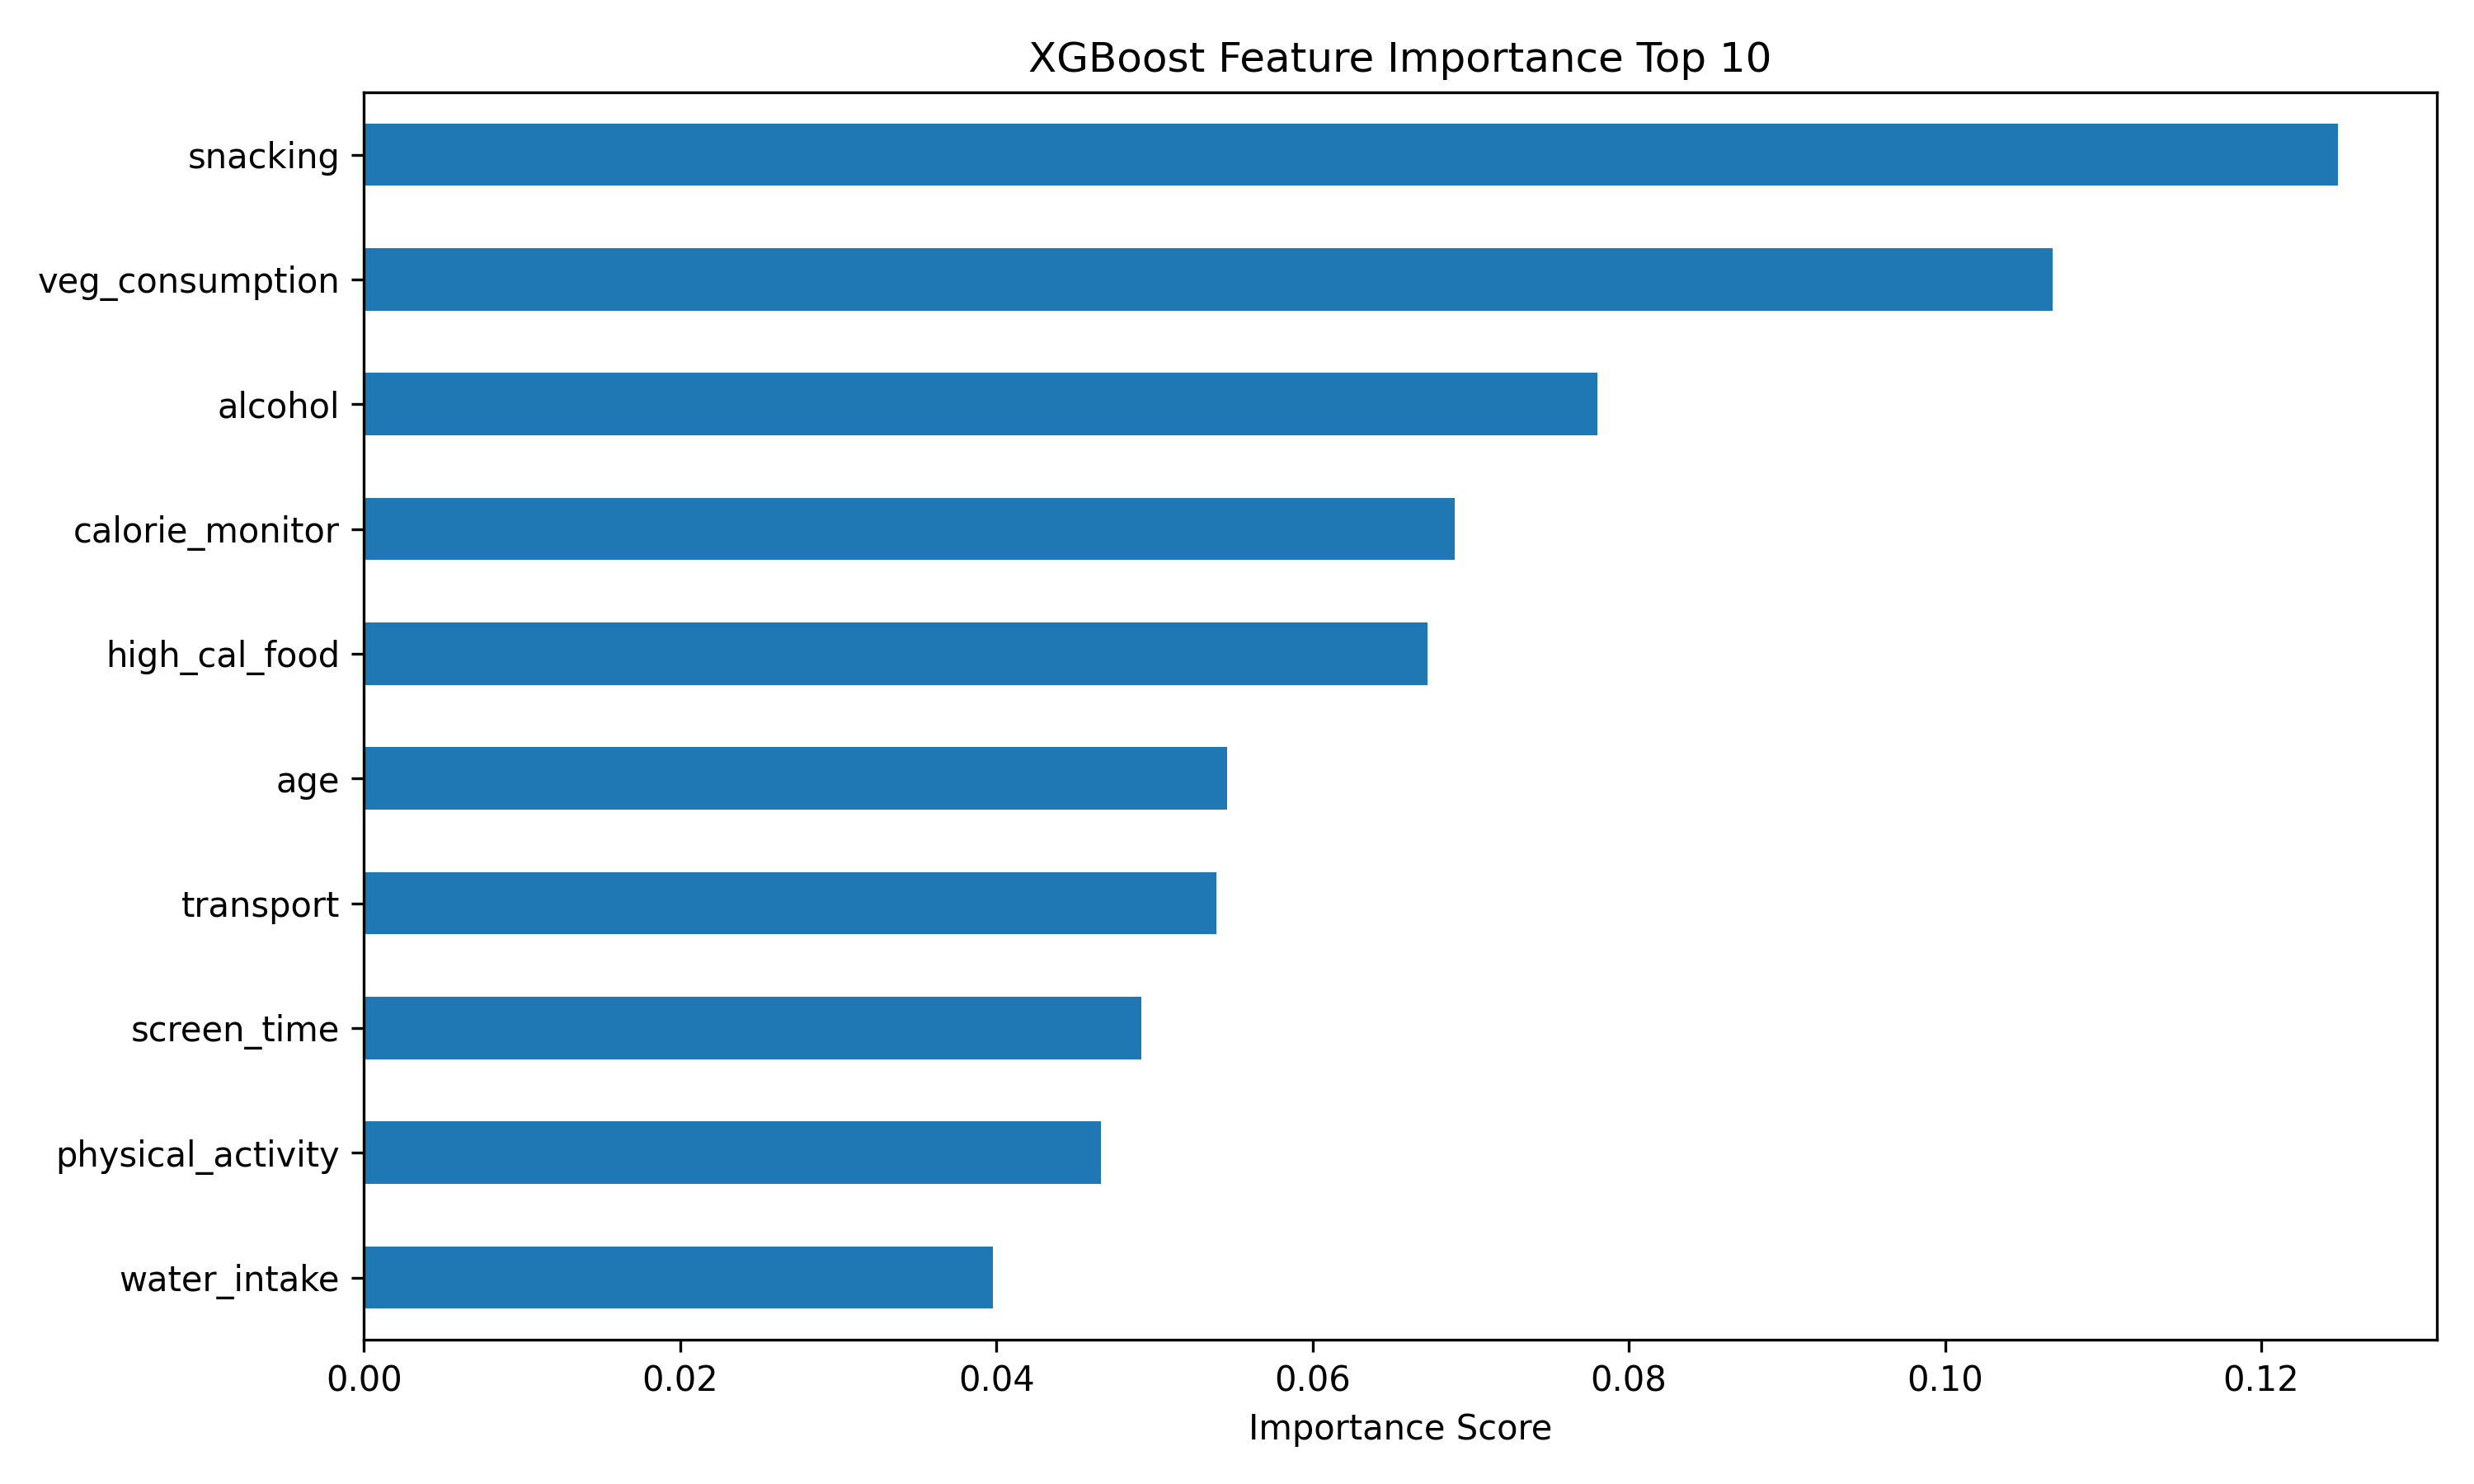

D:\program\INT6184\try\final_model\confusion_matrix.png


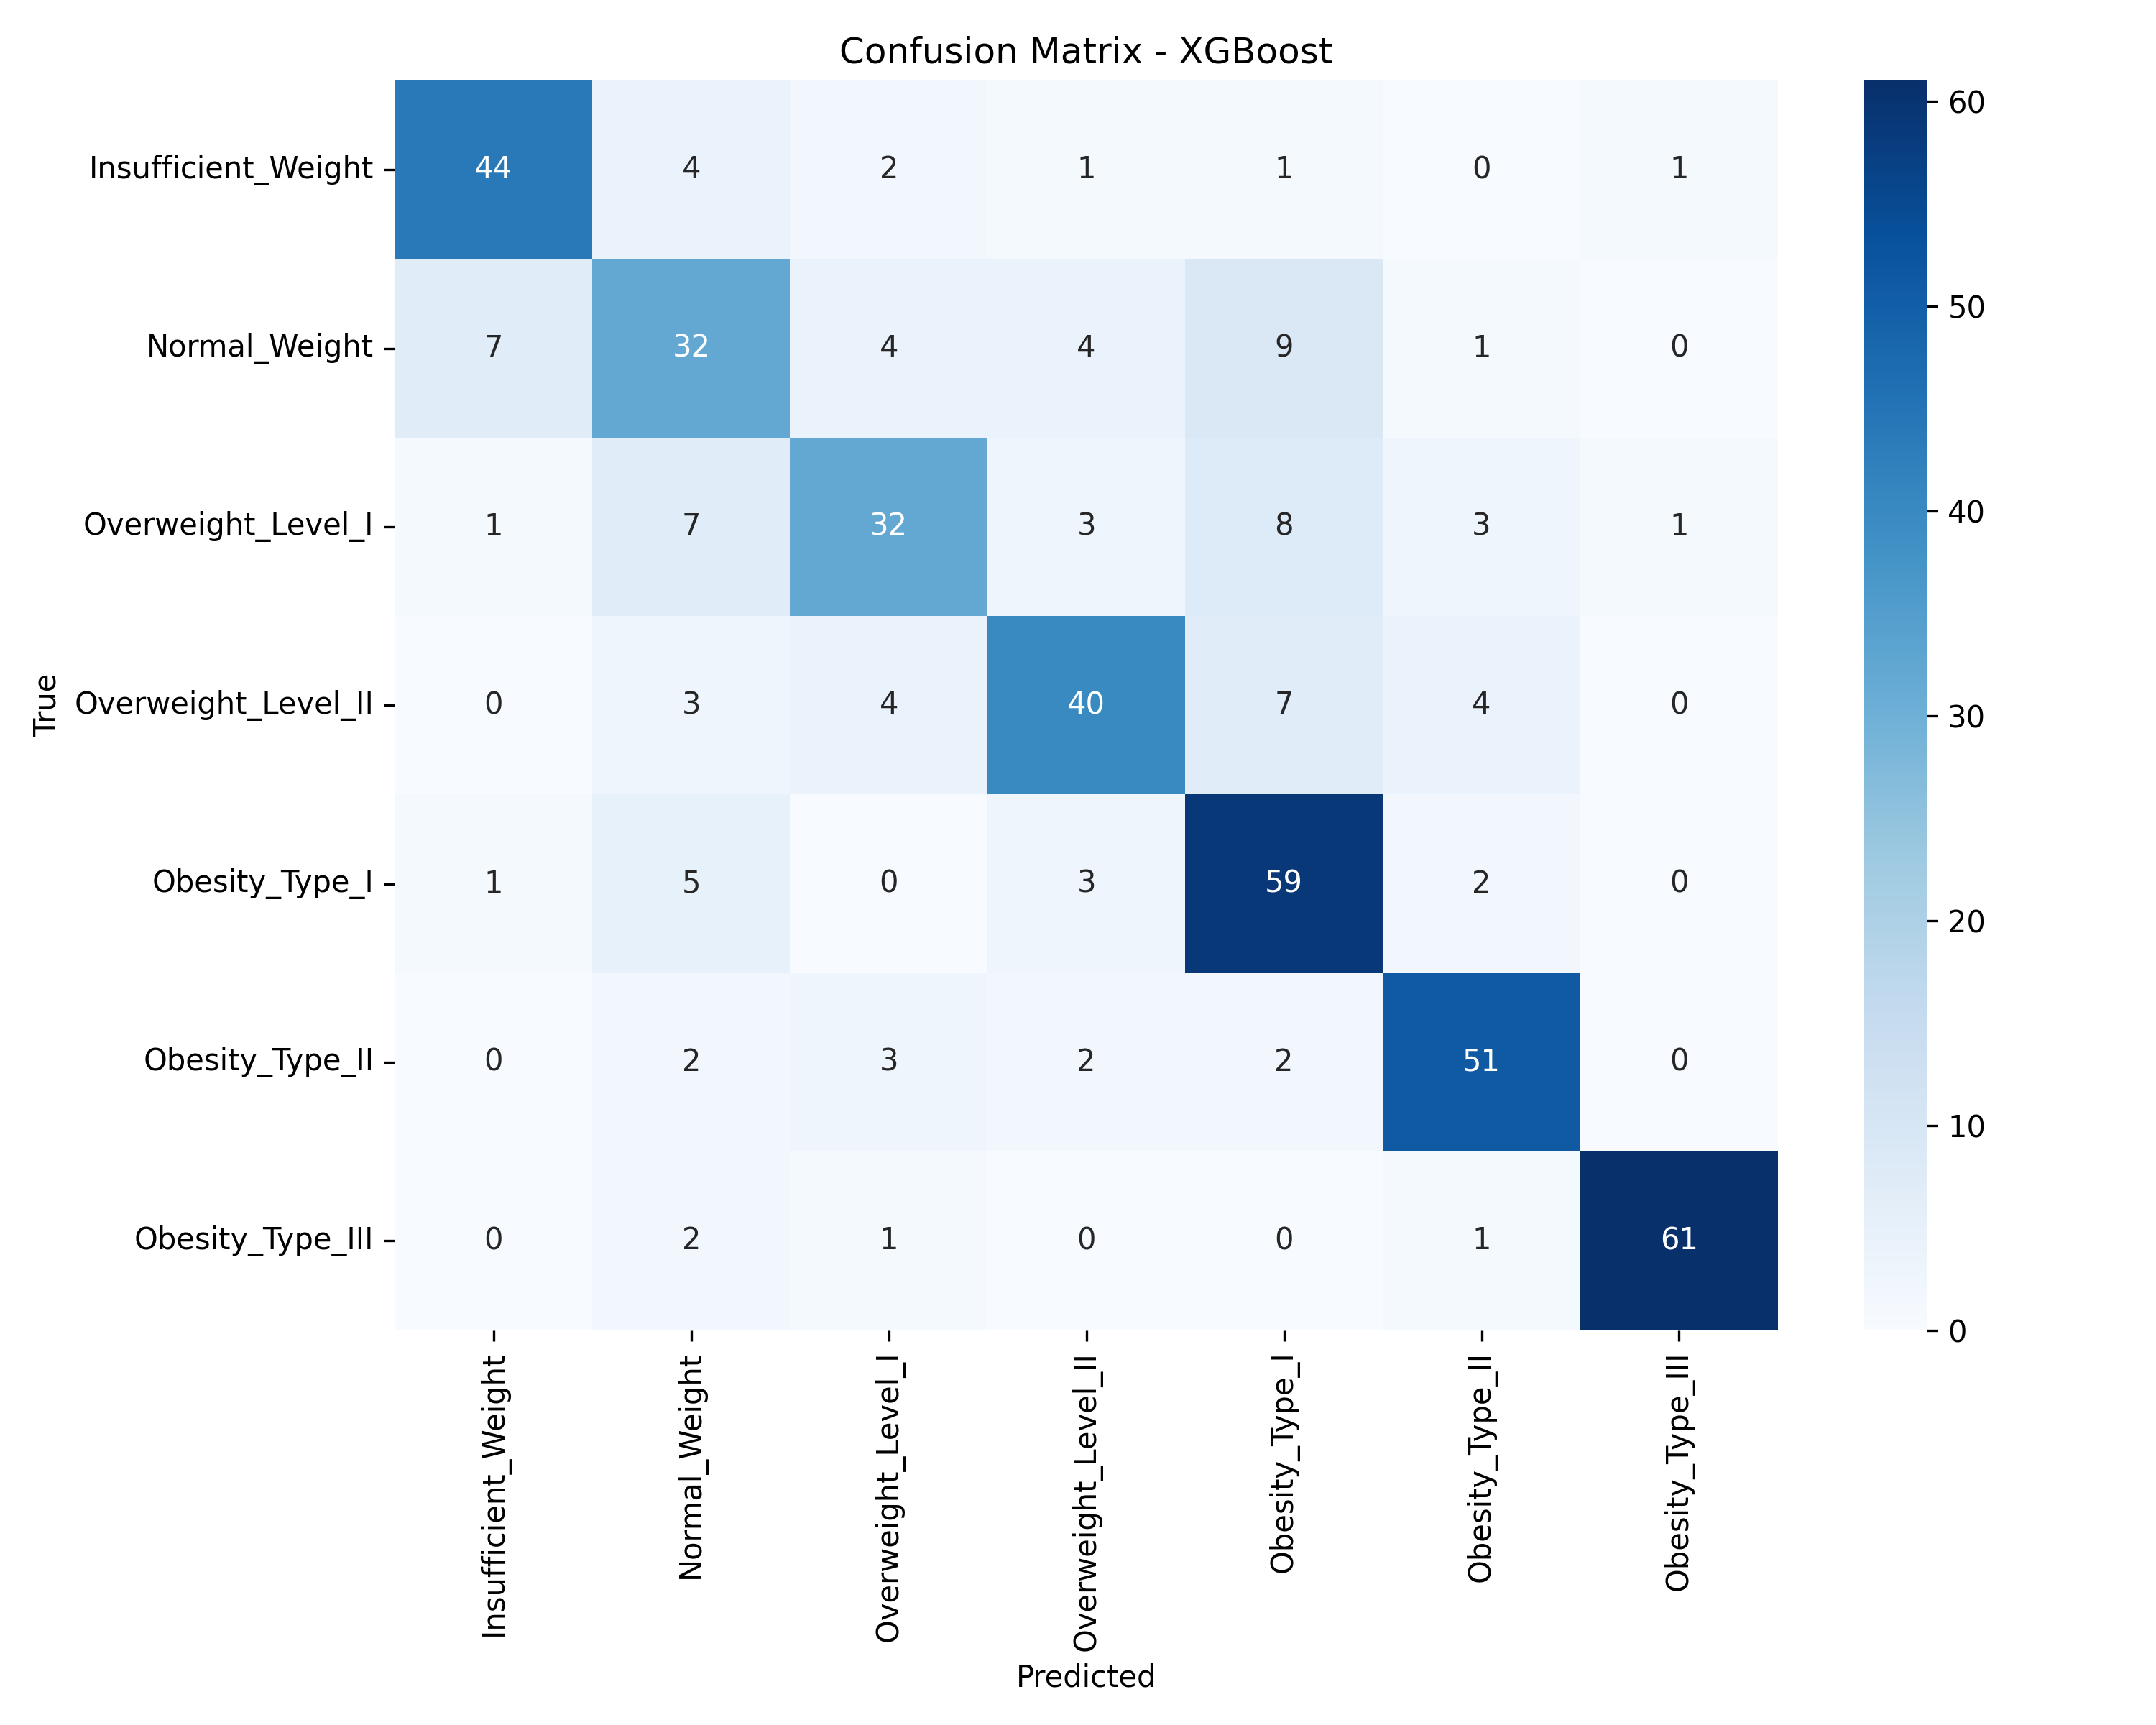

In [26]:
# 在 try/final_model 或当前目录查找 model_final 生成的图（去重）
HERE = Path(".").resolve()
SEARCH_BASES = [
    HERE.parent / "final_model",
    HERE / "final_model",
    HERE,
]
NAMES = ("feature_importance_xgboost.png", "confusion_matrix.png")
found = []
seen = set()
for base in SEARCH_BASES:
    for name in NAMES:
        p = base / name
        rp = p.resolve()
        if p.exists() and rp not in seen:
            seen.add(rp)
            found.append(p)

print("尝试加载建模输出图（若存在）:\n")
for p in found:
    print(p.resolve())
    display(Image(filename=str(p)))

if not found:
    print(
        "未找到 feature_importance_xgboost.png 或 confusion_matrix.png。\n"
        "请先在 try/final_model 目录下运行 model_final.ipynb 生成上述文件，或将图片放在本笔记本当前工作目录后再运行本格。"
    )


---

### 报告撰写提示（与 EDA 衔接建模）

1. **数据说明**：引用本节变量表与「未进入模型」的理由。  
2. **目标分布**：引用频数表与条形图，说明各类别大致均衡。  
3. **特征与等级**：从分类/数值图中挑选 2～3 个最有代表性的模式写入正文。  
4. **质量复检**：概括缺失与重复情况；数值箱线图用于说明无未处理荒谬值即可。  
5. **互证**：对照 XGBoost 特征重要性与混淆矩阵，用中文讨论与 EDA 是否一致。
